# LaundroGraph - Result Analysis and Model Evaluation

This notebook evaluates and contrasts two Graph Neural Network (GNN) paradigms developed for Anti-Money Laundering (AML):
1. **Self-Supervised Link Prediction:** Flags anomalies as structural deviations without using historical labels.
2. **Supervised Edge Classification:** Explicitly trained to classify each transaction edge as *Laundering* or *Normal* using heavily weighted loss functions.

We analyze discriminative performance (ROC-AUC), operational efficiency (Recall@K), robustness to new customers (cold-start), and typology-specific sensitivities.
---

## 1. Environment & Setup
The following cells configure the Colab runtime. This includes downgrading PyTorch to 2.8.0 to align with compatible `torch-sparse` and `torch-geometric` libraries required for our GAT-based graph processing.

In [1]:
# 1. Install the PDF engine (if you haven't already in this session)
!apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-extra texlive-latex-recommended texlive-pictures tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf libavalon-framework-java
  libcommons-logging-java-doc libexcalibur-logkit-java 

In [2]:
print("🚀 SWITCHING TO PYTORCH 2.8 (FAST MODE)...")

# 1. Uninstall the current mismatching versions
# We remove the one you just spent 15 mins compiling, because re-installing
# the CORRECT version via wheels will take only 30 seconds.
# os.system("pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse pyg_lib")
!pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse pyg_lib

# 2. Install PyTorch 2.8.0 (with CUDA 12.6 support)
# We specify the version explicitly to match the PyG documentation you found.
print("⬇️ Installing PyTorch 2.8.0...")
# os.system("pip install torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126")
!pip install torch==2.8.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

# 3. Install Graph Libraries for PyTorch 2.8
# This link matches the table in your screenshot: torch-2.8.0 + cu126
print("⬇️ Installing Graph Libraries (Wheels)...")
# os.system("pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.8.0+cu126.html")
!pip install torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-2.8.0+cu126.html

print("="*40)
print("✅ SETUP COMPLETE.")
print("⚠️ YOU MUST RESTART THE RUNTIME NOW (Runtime -> Restart Session)")
print("="*40)

🚀 SWITCHING TO PYTORCH 2.8 (FAST MODE)...
Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
⬇️ Installing PyTorch 2.8.0...
Looking in indexes: https://download.pytorch.org/whl/cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 125.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 159.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 132.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 86.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 23.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3

In [3]:
import torch

try:
    import torch_sparse
    sparse_status = "✅ Installed"
    sparse_version = torch_sparse.__version__
except ImportError:
    sparse_status = "❌ Not Found"
    sparse_version = "N/A"

print(f"PyTorch Version:      {torch.__version__}")
print(f"CUDA Available:       {torch.cuda.is_available()}")
print(f"Torch Sparse Status:  {sparse_status} ({sparse_version})")

if torch.cuda.is_available() and sparse_status == "✅ Installed":
    print("\nSUCCESS! You are ready to run the training loop.")
else:
    print("\n⚠️ Something is still missing. Did you Restart the Runtime?")

PyTorch Version:      2.8.0+cu126
CUDA Available:       True
Torch Sparse Status:  ✅ Installed (0.6.18+pt28cu126)

SUCCESS! You are ready to run the training loop.


In [4]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.6 MB/s eta 0:00:00


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!pwd

/content


In [7]:
# !jupyter nbconvert --to pdf "/content/drive/MyDrive/Colab Notebooks/LaundroGraph_analysis.ipynb"

In [9]:
import os

os.chdir('/content/drive/MyDrive/LaundroGraph SPML')

In [10]:
! pwd

/content/drive/MyDrive/LaundroGraph SPML


---

## 2. Load Dataset & Model Outputs
We load the pre-constructed SAML-D temporal splits (train/test sets) and the artifacts generated during model training. Specifically, we load:
- The global `HeteroData` graph object.
- The test dataframe containing ground-truth labels and typologies.
- The anomaly scores and embeddings from the **Self-Supervised** model.
- The predicted probabilities and embeddings from the **Supervised** model.

In [11]:
import torch
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, auc, average_precision_score
import seaborn as sns
import umap  # pip install umap-learn

In [12]:
# Load the global heterogeneous graph object and historical data
global_data = torch.load('global_data.pt', weights_only=False)

test_df = pd.read_csv('test_df.csv')
train_df = pd.read_csv('train_df.csv')


with open('customer_to_idx.pkl', 'rb') as f:
# Load the mapping between raw customer IDs and integer indices
    customer_to_idx = pickle.load(f)

In [13]:
# ---------------------------------------------------------
# Load Pre-computed Model Outputs
# ---------------------------------------------------------

# 1. Self-Supervised Model Outputs (Unsupervised Anomaly Detection)
# self supervised model scores/embeddings

anomaly_scores_send = torch.load('anomaly_scores_send_self_sup_02_05_26_v1.pt')
cust_emb_self = torch.load('customer_embeddings_self_sup_02_05_26_v1.pt')
tr_embed_send = torch.load('transaction_embeddings_send_self_sup_02_05_26_v1.pt')


# 2. Supervised Edge Classification Model Outputs
sup_probs = torch.load('sup_probs_02_05_26.pt')
tr_emb_sup = torch.load('sup_z_tx_02_05_26.pt')

### 2.1. Overall Discriminative Performance (ROC AUC)
Plotting the ROC Curve for both models against the test window (~0.7M transactions). Standard rule-based TMS systems suffer from >95% false positives; a high AUC here demonstrates the GNN's ability to discriminate genuine laundering threats.

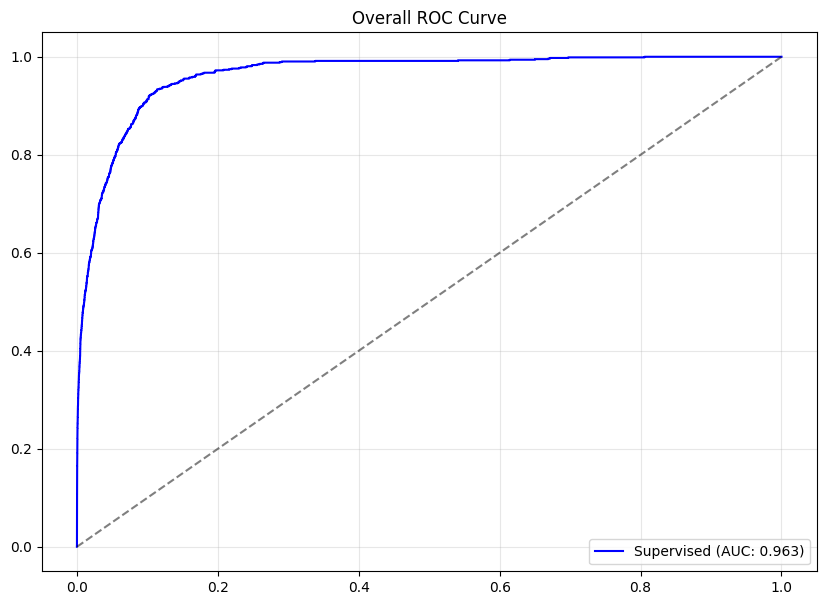

In [14]:
# fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plt.figure(figsize=(10, 7))

# Plot A: ROC Curves (Overall)
fpr_sup, tpr_sup, _ = roc_curve(test_df['Is_laundering'], sup_probs)
# fpr_unsup, tpr_unsup, _ = roc_curve(test_labels, test_probs)

plt.plot(fpr_sup, tpr_sup, label=f'Supervised (AUC: {roc_auc_score(test_df['Is_laundering'], sup_probs):.3f})', color='blue')
# plt.plot(fpr_unsup, tpr_unsup, label=f'Self-Supervised (AUC: {test_auc:.3f})', color='orange')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('Overall ROC Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

---

## 3. Operational Robustness: Known vs. New Customers
In real-world AML, we encounter both 'known' customers (with rich historical profiles) and 'new' customers (cold-start accounts). The `evaluate_and_compare_models` function splits the test set to evaluate if our models generalize well to unseen actors, validating the effectiveness of our residual connections.

In [15]:
# Evaluates models against new and old customers to test cold-start generalization.
def evaluate_and_compare_models(
    sup_probs,
    unsup_scores,
    global_data,
    train_df,
    test_df
):
    print("--- Final Model Comparison (User Logic) ---")

    # 1. PREPARE PREDICTIONS
    y_sup = sup_probs.detach().cpu().numpy().flatten()
    y_unsup = unsup_scores.detach().cpu().numpy().flatten()

    # Safety Check for Lengths
    if len(y_sup) != len(test_df):
        print(f"Length mismatch (Preds: {len(y_sup)}, DF: {len(test_df)}). Using Graph Labels.")
        y_true = global_data['customer', 'sends', 'transaction'].edge_label[global_data.test_mask_ids].cpu().numpy()
    else:
        y_true = test_df['Is_laundering'].values

    # Auto-correct Self-Supervised Scores if inverted
    if roc_auc_score(y_true, y_unsup) < 0.5:
        print("Inverting Self-Supervised scores...")
        y_unsup = 1.0 - y_unsup

    # ---------------------------------------------------------
    # 2. YOUR LOGIC: IDENTIFY KNOWN vs. NEW CUSTOMERS
    # ---------------------------------------------------------
    print("Applying User Logic for Customer History...")

    # A. Identify Customers who have history (Union of Senders & Receivers in Train)
    train_senders = set(train_df['Sender_account'].unique())
    train_receivers = set(train_df['Receiver_account'].unique())
    known_customers = train_senders.union(train_receivers)

    # B. Create Mask: True if SENDER exists in training
    mask_known = test_df['Sender_account'].isin(known_customers).values
    mask_new = ~mask_known

    # C. Print Statistics
    n_known = sum(mask_known)
    n_new = len(test_df) - n_known

    print(f"   Total Test Transactions: {len(test_df)}")
    print(f"   • Transactions by Known Senders: {n_known:,} ({n_known/len(test_df)*100:.1f}%)")
    print(f"   • Transactions by New Senders:   {n_new:,}   ({n_new/len(test_df)*100:.1f}%)")
    print(f"   Test set laundering rate: {y_true.mean()*100:.4f}%")

    if n_known == 0:
        print("Error: No overlap! Check your train/test split logic.")
        return

    # ---------------------------------------------------------
    # 3. CALCULATE METRICS (AUC & AP)
    # ---------------------------------------------------------
    results = {}

    def get_metrics(labels, scores):
        if len(np.unique(labels)) < 2: return 0.0, 0.0
        return roc_auc_score(labels, scores), average_precision_score(labels, scores)

    # Full Set
    auc_sup_all, ap_sup_all = get_metrics(y_true, y_sup)
    auc_unsup_all, ap_unsup_all = get_metrics(y_true, y_unsup)
    results['Sup_All'] = auc_sup_all
    results['Unsup_All'] = auc_unsup_all

    # Known Customers (Old)
    auc_sup_old, ap_sup_old = get_metrics(y_true[mask_known], y_sup[mask_known])
    auc_unsup_old, ap_unsup_old = get_metrics(y_true[mask_known], y_unsup[mask_known])
    results['Sup_Old'] = auc_sup_old
    results['Unsup_Old'] = auc_unsup_old

    # New Customers (Cold Start)
    auc_sup_new, ap_sup_new = get_metrics(y_true[mask_new], y_sup[mask_new])
    auc_unsup_new, ap_unsup_new = get_metrics(y_true[mask_new], y_unsup[mask_new])
    results['Sup_New'] = auc_sup_new
    results['Unsup_New'] = auc_unsup_new

    print("\n--- PERFORMANCE SUMMARY ---")
    print(f"KNOWN Senders (History Available):")
    print(f"   Supervised AUC: {auc_sup_old:.4f} | AP: {ap_sup_old:.4f}")
    print(f"   Unsupervised AUC: {auc_unsup_old:.4f} | AP: {ap_unsup_old:.4f}")
    print(f"NEW Senders (Cold Start):")
    print(f"   Supervised AUC: {auc_sup_new:.4f} | AP: {ap_sup_new:.4f}")
    print(f"   Unsupervised AUC: {auc_unsup_new:.4f} | AP: {ap_unsup_new:.4f}")

    # ---------------------------------------------------------
    # 4. PLOTTING
    # Generates a Bar chart comparing model robustness on cold-start users vs users with history
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Plot A: ROC Curves (Overall)
    fpr_sup, tpr_sup, _ = roc_curve(y_true, y_sup)
    fpr_unsup, tpr_unsup, _ = roc_curve(y_true, y_unsup)

    axes[0].plot(fpr_sup, tpr_sup, label=f'Supervised (AUC: {auc_sup_all:.3f})', color='blue')
    axes[0].plot(fpr_unsup, tpr_unsup, label=f'Self-Supervised (AUC: {auc_unsup_all:.3f})', color='orange')
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[0].set_title('Overall ROC Curve')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)

    # Plot B: Robustness Bar Chart
    labels = [f'Known Senders\n({n_known} Txs)', f'New Senders\n({n_new} Txs)']
    sup_scores = [results['Sup_Old'], results['Sup_New']]
    unsup_scores = [results['Unsup_Old'], results['Unsup_New']]

    x = np.arange(len(labels))
    width = 0.35

    rects1 = axes[1].bar(x - width/2, sup_scores, width, label='Supervised', color='blue', alpha=0.7)
    rects2 = axes[1].bar(x + width/2, unsup_scores, width, label='Self-Supervised', color='orange', alpha=0.7)

    axes[1].set_ylabel('ROC AUC Score')
    axes[1].set_title('Robustness: Generalization to New Users')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].legend()
    axes[1].set_ylim(0.4, 1.05)
    axes[1].grid(axis='y', alpha=0.3)

    # Annotate bars
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            axes[1].annotate(f'{height:.3f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()

    return results

# Example Usage:
# results = evaluate_and_compare_models_final_logic(sup_probs, unsup_scores, global_data, train_df, test_df)

In [16]:
old_cust = list(set(pd.concat([train_df['Sender_account'], train_df['Receiver_account']]).unique()))
old_mask = test_df['Sender_account'].isin(old_cust)

In [17]:
roc_auc_score(test_df['Is_laundering'], anomaly_scores_send), roc_auc_score(test_df['Is_laundering'], sup_probs)

(np.float64(0.6693055600875852), np.float64(0.9633021343508206))

In [18]:
anomaly_scores_send[old_mask].shape, sup_probs[old_mask].shape

(torch.Size([517096]), torch.Size([517096]))

In [19]:
roc_auc_score(test_df['Is_laundering'][old_mask], anomaly_scores_send[old_mask]), roc_auc_score(test_df['Is_laundering'][old_mask], sup_probs[old_mask])

(np.float64(0.7848639071268382), np.float64(0.955859600547115))

In [20]:
roc_auc_score(test_df['Is_laundering'][~old_mask], anomaly_scores_send[~old_mask]), roc_auc_score(test_df['Is_laundering'][~old_mask], sup_probs[~old_mask])

(np.float64(0.8642864824174643), np.float64(0.9998852923253396))

In [21]:
old_mask.sum(), (~old_mask).sum()

(np.int64(517096), np.int64(139486))

--- Final Model Comparison (User Logic) ---
Applying User Logic for Customer History...
   Total Test Transactions: 656582
   • Transactions by Known Senders: 517,096 (78.8%)
   • Transactions by New Senders:   139,486   (21.2%)
   Test set laundering rate: 0.1264%

--- PERFORMANCE SUMMARY ---
KNOWN Senders (History Available):
   Supervised AUC: 0.9559 | AP: 0.1443
   Unsupervised AUC: 0.7849 | AP: 0.0064
NEW Senders (Cold Start):
   Supervised AUC: 0.9999 | AP: 0.0588
   Unsupervised AUC: 0.8643 | AP: 0.0001


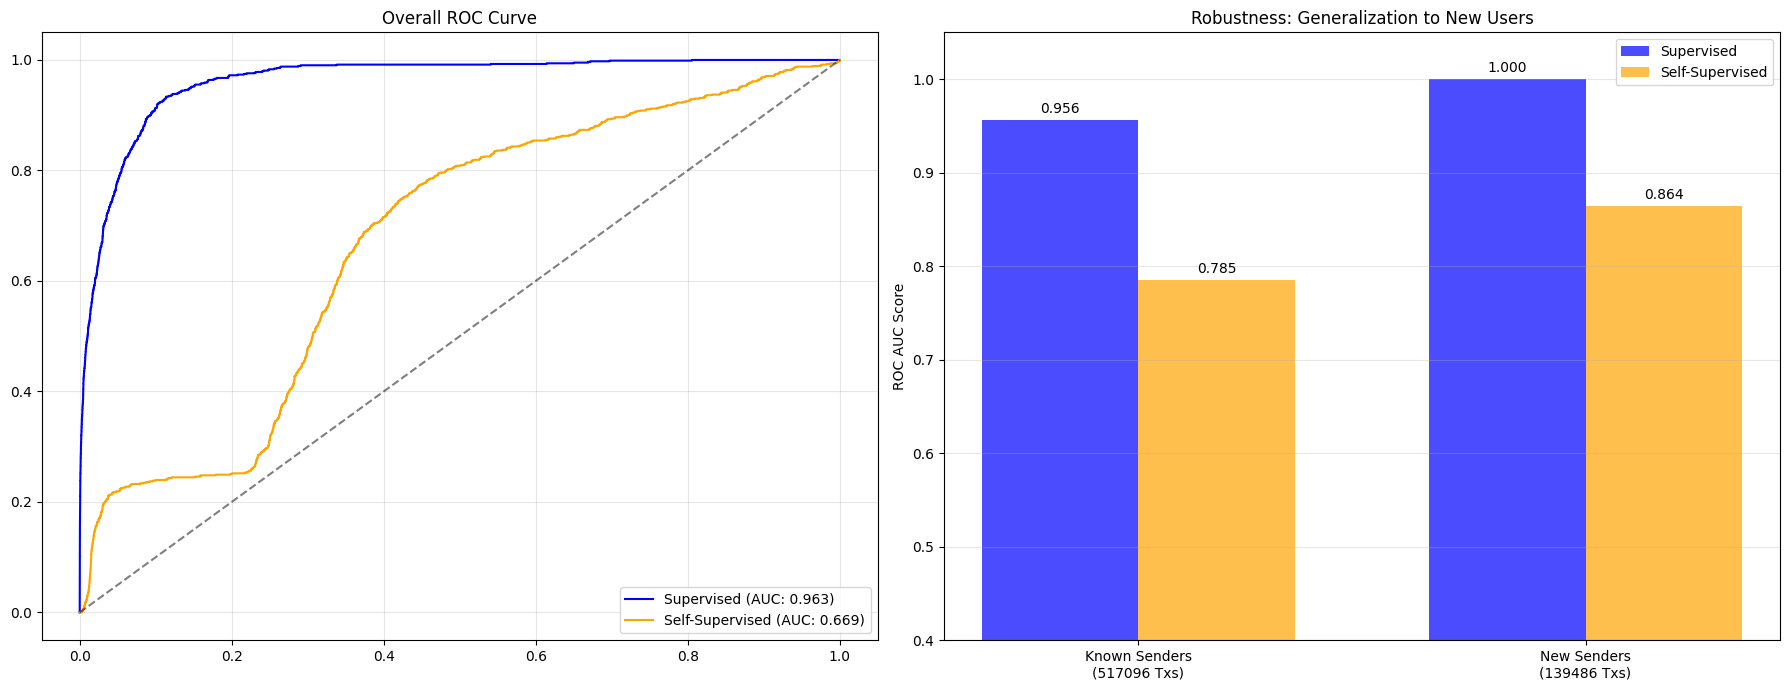

In [22]:
# --- EXECUTE ---
comparison_results = evaluate_and_compare_models(
    sup_probs,          # Your Supervised Tensor
    anomaly_scores_send,# Your Self-Supervised Tensor
    global_data,
    train_df,
    test_df
)

---

## 4. Model Overlap Analysis (Complementary Dual-Tier Pipeline)
We evaluate the intersection of the Top K% most suspicious alerts from both models. This determines if the models are redundant or complementary.
- **Intersection:** High-confidence alerts (anomalous & flagged).
- **Supervised Only:** Label-driven pattern matches (structural mimicry of legal flows).
- **Self-Supervised Only:** Pure structural anomalies (potential novel typologies).

In [23]:
# Compares Top K% overlap between structural anomaly detections and supervised label-based detections.
def analyze_model_overlap(df, unsup_scores, sup_probs, top_k_percent=0.01):
    """
    Compares the overlap between detections of two models.
    unsup_scores: Anomaly Scores (Higher = Weird)
    sup_probs: Laundering Probability (Higher = Guilty)
    """
    y_true = df['Is_laundering'].values
    k = int(len(df) * top_k_percent)

    print(f"--- Top {top_k_percent*100}% Alert Analysis (Top {k} transactions) ---")

    # 1. Get Indices of Top-K Alerts for both models
    # argsort sorts ascending, so we take the last k elements
    top_unsup_idx = np.argsort(unsup_scores)[-k:]
    top_sup_idx   = np.argsort(sup_probs)[-k:]

    set_unsup = set(top_unsup_idx)
    set_sup   = set(top_sup_idx)

    # 2. Calculate Intersections
    both = set_unsup.intersection(set_sup)
    only_unsup = set_unsup - set_sup
    only_sup   = set_sup - set_unsup

    # 3. Helper to check how many real criminals are in a set
    def check_success(indices):
        if len(indices) == 0: return 0, 0.0
        real_crimes = y_true[list(indices)].sum()
        precision = real_crimes / len(indices)
        return int(real_crimes), precision

    # 4. Print Results
    count_both, prec_both = check_success(both)
    count_unsup, prec_unsup = check_success(only_unsup)
    count_sup, prec_sup = check_success(only_sup)

    print(f"\n1. INTERSECTION (Flagged by BOTH): {len(both)}")
    print(f"   - Confirmed Launderers found: {count_both}")
    print(f"   - Precision: {prec_both:.4f}")

    print(f"\n2. SUPERVISED ONLY (Pattern Matching): {len(only_sup)}")
    print(f"   - Confirmed Launderers found: {count_sup}")
    print(f"   - Precision: {prec_sup:.4f}")

    print(f"\n3. SELF-SUPERVISED ONLY (Structural Anomaly): {len(only_unsup)}")
    print(f"   - Confirmed Launderers found: {count_unsup}")
    print(f"   - Precision: {prec_unsup:.4f}")

    return list(both), list(only_unsup), list(only_sup)

In [24]:
# Run it
intersect, unique_unsup, unique_sup = analyze_model_overlap(test_df, np.array(anomaly_scores_send),
                                                            np.array(sup_probs))

--- Top 1.0% Alert Analysis (Top 6565 transactions) ---

1. INTERSECTION (Flagged by BOTH): 248
   - Confirmed Launderers found: 20
   - Precision: 0.0806

2. SUPERVISED ONLY (Pattern Matching): 6317
   - Confirmed Launderers found: 388
   - Precision: 0.0614

3. SELF-SUPERVISED ONLY (Structural Anomaly): 6317
   - Confirmed Launderers found: 4
   - Precision: 0.0006


---

## 5. Embedding Space Visualization (UMAP)
We use UMAP to project the learned 64-dimensional transaction embeddings into a 2D plane.
This visually validates the core thesis:
- The **Supervised** model reshapes the space to isolate laundering ('guilt').
- The **Self-Supervised** model groups by structural similarity, failing when criminals mimic legitimate typologies (e.g., payroll).

In [25]:
# Uses UMAP dimensionality reduction to visualize learned embeddings.
# Stratifies sample to 5000 normal + all laundering transactions.
def plot_model_comparison_separate(
    sup_embeddings, unsup_embeddings,
    full_df, test_indices,
    num_normal=5000
):
    print("--- Starting Visualization (4 Separate Plots) ---")

    # ---------------------------------------------------------
    # 1. STRATIFIED SAMPLING & PREP (Same as before)
    # ---------------------------------------------------------
    test_labels = full_df.iloc[test_indices]['Is_laundering'].values
    idx_laundering = np.where(test_labels == 1)[0]
    idx_normal = np.where(test_labels == 0)[0]

    if len(idx_normal) > num_normal:
        idx_normal_sampled = np.random.choice(idx_normal, num_normal, replace=False)
    else:
        idx_normal_sampled = idx_normal

    sampled_relative_idx = np.concatenate([idx_laundering, idx_normal_sampled])
    np.random.shuffle(sampled_relative_idx)

    print(f"  Plotting {len(sampled_relative_idx)} points ({len(idx_laundering)} Laundering)...")

    # Slice Embeddings & DF
    z_sup = sup_embeddings[sampled_relative_idx]
    z_unsup = unsup_embeddings[sampled_relative_idx]

    global_ids_to_plot = test_indices[sampled_relative_idx]
    df_subset = full_df.iloc[global_ids_to_plot].copy()

    # Get Labels
    y_class = df_subset['Is_laundering'].values

    # Typology Logic
    if 'Laundering_type' in df_subset.columns:
        y_type = df_subset['Laundering_type'].values
    elif 'Type' in df_subset.columns:
        y_type = df_subset['Type'].values
    else:
        y_type = ['Unknown'] * len(df_subset)

    # Combined Label
    combined_labels = []
    for typ, cls in zip(y_type, y_class):
        status = "Laundering" if cls == 1 else "Normal"
        typ_clean = str(typ).replace('_', ' ')
        combined_labels.append(f"{typ_clean} ({status})")
    df_subset['Combined_Label'] = combined_labels

    # ---------------------------------------------------------
    # 2. RUN UMAP (Same as before)
    # ---------------------------------------------------------
    print("  Running UMAP for Supervised Model...")
    reducer_sup = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
    z_sup_2d = reducer_sup.fit_transform(z_sup)

    print("  Running UMAP for Self-Supervised Model...")
    reducer_unsup = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
    z_unsup_2d = reducer_unsup.fit_transform(z_unsup)

    # Prepare DataFrame
    df_plot = pd.DataFrame({
        'sup_x': z_sup_2d[:, 0], 'sup_y': z_sup_2d[:, 1],
        'unsup_x': z_unsup_2d[:, 0], 'unsup_y': z_unsup_2d[:, 1],
        'Class': ['Laundering' if v==1 else 'Normal' for v in y_class],
        'Detailed_Typology': df_subset['Combined_Label'].values
    })

    # ---------------------------------------------------------
    # 3. GENERATE 4 SEPARATE PLOTS
    # ---------------------------------------------------------

    # --- PLOT 1: Supervised - Class Separation ---
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df_plot, x='sup_x', y='sup_y', hue='Class',
                    palette={'Normal': 'lightgrey', 'Laundering': 'red'},
                    alpha=0.6, s=20)
    plt.title("Supervised Model: Class Separation (Guilt)")
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show() # Displays Plot 1

    # --- PLOT 2: Supervised - Detailed Typology ---
    plt.figure(figsize=(12, 8)) # Wider for legend
    sns.scatterplot(data=df_plot, x='sup_x', y='sup_y', hue='Detailed_Typology',
                    palette='tab20', alpha=0.7, s=20)
    plt.title("Supervised Model: Detailed Typologies")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Typology")
    plt.tight_layout()
    plt.show() # Displays Plot 2

    # --- PLOT 3: Self-Supervised - Class Separation ---
    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=df_plot, x='unsup_x', y='unsup_y', hue='Class',
                    palette={'Normal': 'lightgrey', 'Laundering': 'red'},
                    alpha=0.6, s=20)
    plt.title("Self-Supervised Model: Class Separation (Guilt)")
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show() # Displays Plot 3

    # --- PLOT 4: Self-Supervised - Detailed Typology ---
    plt.figure(figsize=(12, 8)) # Wider for legend
    sns.scatterplot(data=df_plot, x='unsup_x', y='unsup_y', hue='Detailed_Typology',
                    palette='tab20', alpha=0.7, s=20)
    plt.title("Self-Supervised Model: Detailed Typologies")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Typology")
    plt.tight_layout()
    plt.show() # Displays Plot 4

--- Starting Visualization (4 Separate Plots) ---
  Plotting 5830 points (830 Laundering)...
  Running UMAP for Supervised Model...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Running UMAP for Self-Supervised Model...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


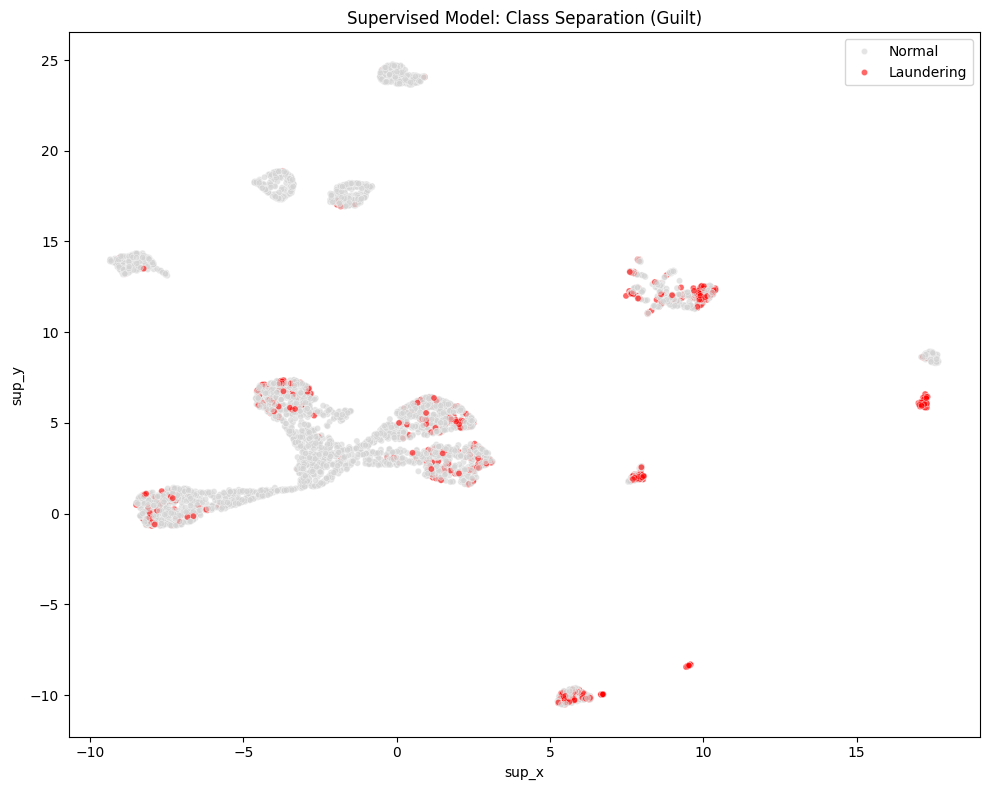

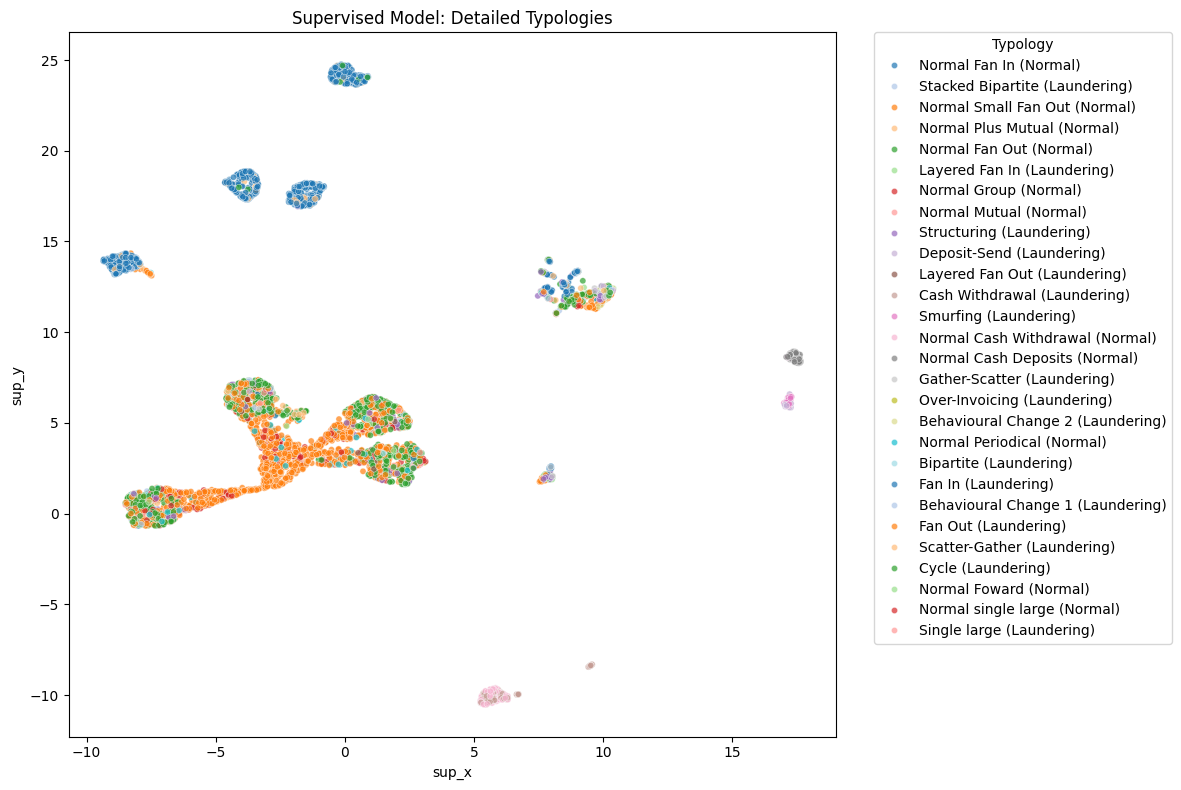

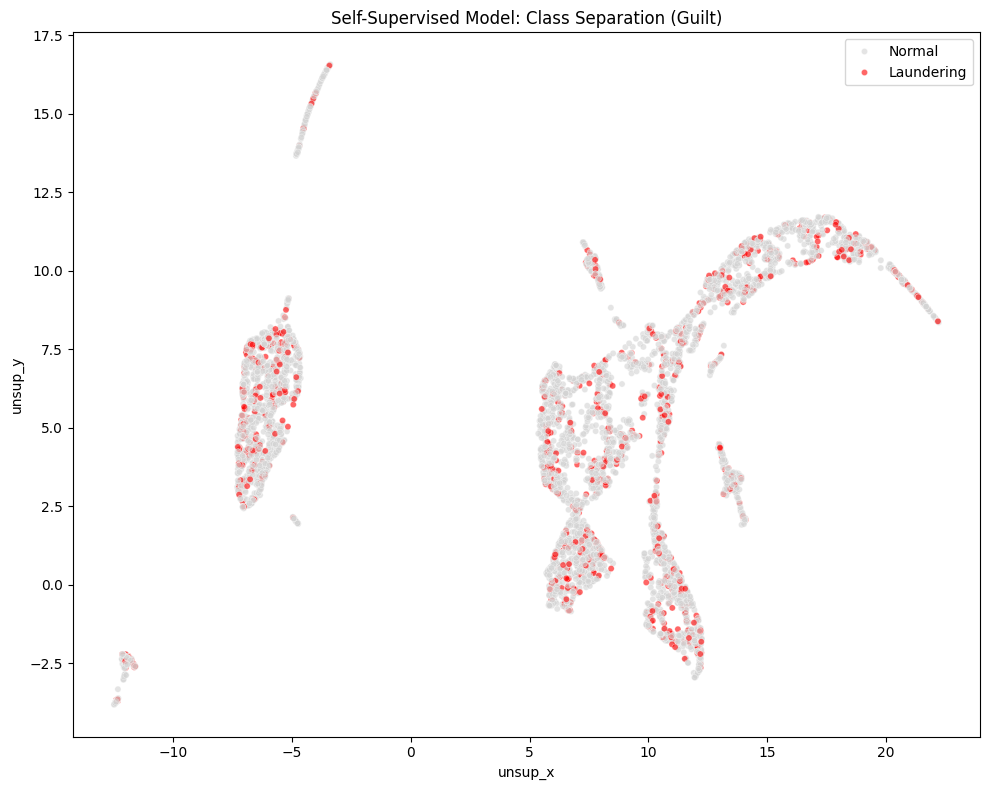

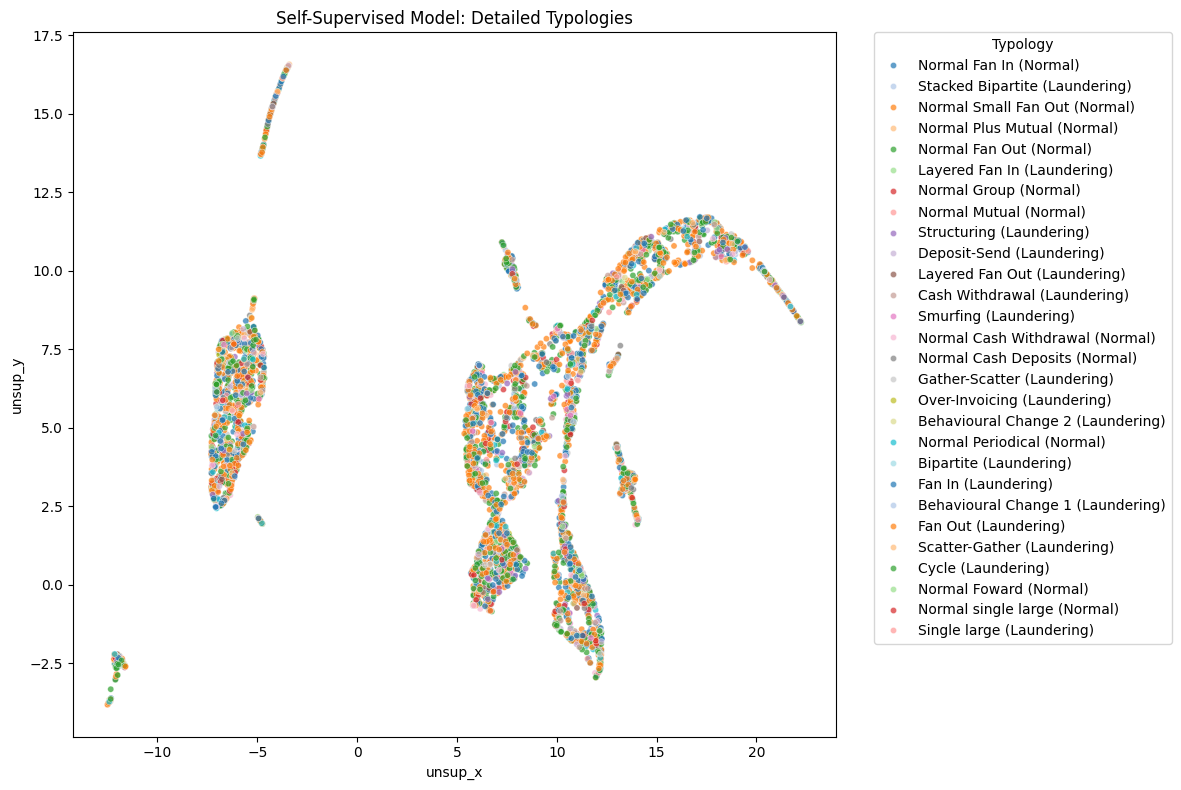

In [ ]:
# --- EXECUTE ---
test_indices_np = global_data.test_mask_ids.cpu().numpy()

# Ensure full_df exists
full_df = pd.concat([train_df, test_df], ignore_index=True)

plot_model_comparison_separate(
    tr_emb_sup,
    tr_embed_send,
    full_df,
    test_indices_np,
    num_normal=5000
)

---

## 6. Typology-Specific Sensitivity & Operational Efficiency (Recall@K)
Real-world compliance teams operate under fixed 'alert budgets' (e.g., they can only review the top 5% of transactions). Here we compute Recall@K to measure the operational viability of the models. We also breakdown AUC by specific typologies (e.g., Smurfing vs. Cash Withdrawals).

In [26]:
# Analyzes AUC across specific laundering types (Smurfing, Fan-In, etc) and calculates Recall @ Top K%
def analyze_typology_and_ranking_grouped(
    sup_probs,
    unsup_scores,
    full_df,
    # test_indices
):
    print("--- Starting Deep Dive Analysis (Grouped < 40) ---")

    # 1. PREPARE DATA
    y_sup = sup_probs.detach().cpu().numpy().flatten()
    y_unsup = unsup_scores.detach().cpu().numpy().flatten()

    # Slice DataFrame to Test Set
    df_test = full_df.copy()
    df_test['Score_Sup'] = y_sup
    df_test['Score_Unsup'] = y_unsup

    # Auto-Invert Self-Supervised if needed
    if roc_auc_score(df_test['Is_laundering'], df_test['Score_Unsup']) < 0.5:
        print("Note: Inverting Self-Supervised scores for analysis...")
        df_test['Score_Unsup'] = 1.0 - df_test['Score_Unsup']

    # ---------------------------------------------------------
    # PART A: PERFORMANCE BY TYPOLOGY
    # ---------------------------------------------------------
    print("\n1. Calculating AUC by Typology...")

    # Get Typology Column
    if 'Laundering_type' in df_test.columns:
        type_col = 'Laundering_type'
    elif 'Type' in df_test.columns:
        type_col = 'Type'
    else:
        print("Error: No typology column found.")
        return

    # --- [NEW] GROUPING LOGIC START ---
    # To avoid noisy AUC calculations on rare typologies, any type with < 40 examples is binned into 'Other'
    # 1. Count instances per typology (only for actual laundering cases)
    laundering_mask = df_test['Is_laundering'] == 1
    type_counts = df_test.loc[laundering_mask, type_col].value_counts()

    # 2. Identify types with less than 40 cases
    threshold = 40
    small_types = type_counts[type_counts < threshold].index
    print(f"Grouping {len(small_types)} typologies into 'Other' (each has < {threshold} samples).")

    # 3. Replace these types with 'Other' in the dataframe
    # We use .loc to modify only the rows that match the criteria
    df_test.loc[laundering_mask & df_test[type_col].isin(small_types), type_col] = 'Other'
    # --- [NEW] GROUPING LOGIC END ---

    # Filter for Laundering transactions only to get the list of unique types
    # (This list now includes 'Other' and excludes the small ones)
    laundering_types = df_test[df_test['Is_laundering'] == 1][type_col].unique()

    results = []
    df_normal = df_test[df_test['Is_laundering'] == 0]

    for l_type in laundering_types:
        # Get just this specific crime type
        df_crime = df_test[(df_test[type_col] == l_type) & (df_test['Is_laundering'] == 1)]

        # Combine with Normal for 1-vs-All AUC
        df_eval = pd.concat([df_crime, df_normal])

        # Calculate AUCs
        # (We keep the >5 check just in case 'Other' is still very small, though unlikely)
        if len(df_crime) > 5:
            auc_sup = roc_auc_score(df_eval['Is_laundering'], df_eval['Score_Sup'])
            auc_unsup = roc_auc_score(df_eval['Is_laundering'], df_eval['Score_Unsup'])

            results.append({
                'Typology': str(l_type).replace('_', ' '),
                'Count': len(df_crime),
                'Supervised AUC': auc_sup,
                'Self-Supervised AUC': auc_unsup
            })

    # Sort results for better plotting
    df_results = pd.DataFrame(results).sort_values('Self-Supervised AUC', ascending=False)

    # --- PLOT TYPOLOGY RESULTS ---
    plt.figure(figsize=(12, 6))

    # Melt for Seaborn
    df_melt = df_results.melt(id_vars=['Typology', 'Count'], var_name='Model', value_name='AUC')

    sns.barplot(data=df_melt, x='Typology', y='AUC', hue='Model', palette={'Supervised AUC': 'blue', 'Self-Supervised AUC': 'orange'})
    plt.ylim(0.4, 1.05)
    plt.title("Model Sensitivity by Money Laundering Typology")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(df_results[['Typology', 'Count', 'Supervised AUC', 'Self-Supervised AUC']])

    # ---------------------------------------------------------
    # PART B: PRECISION @ K (Operational Effectiveness)
    # ---------------------------------------------------------
    print("\n2. Calculating Precision @ K...")

    # Calculate Precision at top 0.1%, 0.5%, 1%, 5%
    k_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

    p_at_k_results = []
    total_laundering = df_test['Is_laundering'].sum()
    n_test = len(df_test)

    for k_frac in k_values:
        k_count = int(n_test * k_frac)

        # Sort by Score Descending
        top_k_sup = df_test.nlargest(k_count, 'Score_Sup')
        top_k_unsup = df_test.nlargest(k_count, 'Score_Unsup')

        # Count hits
        hits_sup = top_k_sup['Is_laundering'].sum()
        hits_unsup = top_k_unsup['Is_laundering'].sum()

        # Calculate Recall (How many of total bad guys did we catch?)
        rec_sup = hits_sup / total_laundering
        rec_unsup = hits_unsup / total_laundering

        p_at_k_results.append({
            'Top K %': f"{k_frac*100}%",
            'Alerts Generated': k_count,
            'Sup Recall': rec_sup,
            'Unsup Recall': rec_unsup
        })

    df_pk = pd.DataFrame(p_at_k_results)

    # --- PLOT RECALL @ K ---
    plt.figure(figsize=(10, 6))
    x = np.arange(len(k_values))
    width = 0.35

    plt.bar(x - width/2, df_pk['Sup Recall'], width, label='Supervised', color='blue', alpha=0.7)
    plt.bar(x + width/2, df_pk['Unsup Recall'], width, label='Self-Supervised', color='orange', alpha=0.7)

    plt.xticks(x, df_pk['Top K %'])
    plt.ylabel('Recall (Percentage of Total Laundering Caught)')
    plt.xlabel('Top % of Transactions Flagged (Budget)')
    plt.title('Recall @ Top K: Operational Efficiency')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\n--- Operational Stats (Recall @ Top K) ---")
    print(df_pk)

--- Starting Deep Dive Analysis (Grouped < 40) ---

1. Calculating AUC by Typology...
Grouping 8 typologies into 'Other' (each has < 40 samples).


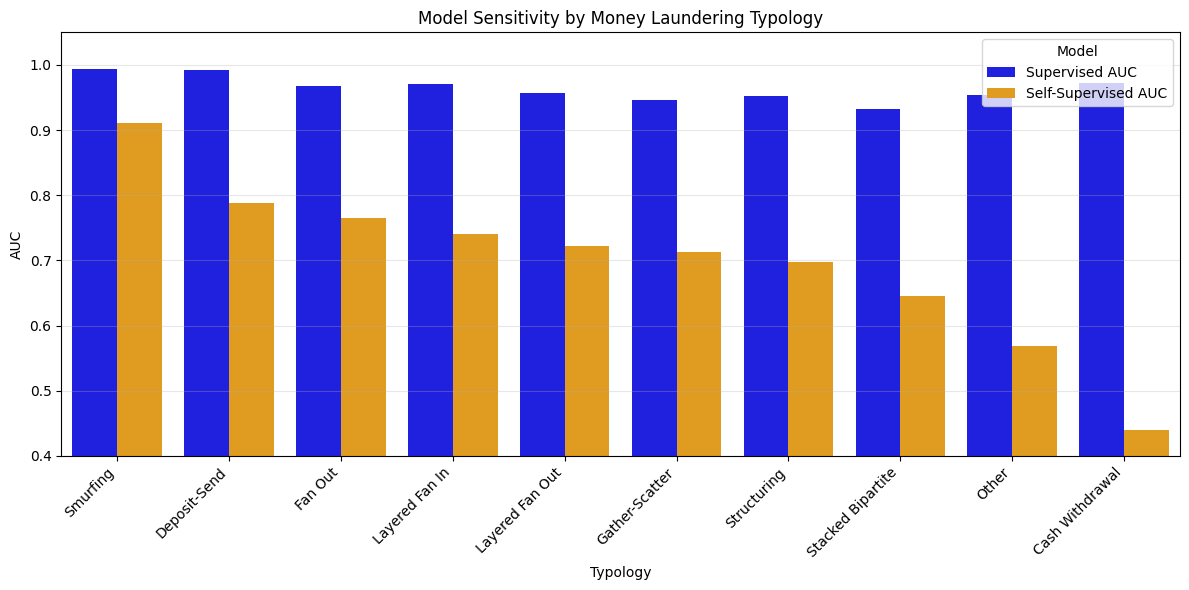

            Typology  Count  Supervised AUC  Self-Supervised AUC
5           Smurfing     81        0.994078             0.911091
6       Deposit-Send     68        0.992556             0.787490
9            Fan Out     46        0.967694             0.765425
3     Layered Fan In     47        0.970848             0.741028
2    Layered Fan Out     46        0.957218             0.722922
4     Gather-Scatter     41        0.946853             0.713287
8        Structuring    173        0.952381             0.697420
0  Stacked Bipartite     84        0.932929             0.645128
1              Other    105        0.954005             0.569009
7    Cash Withdrawal    139        0.972888             0.439198

2. Calculating Precision @ K...


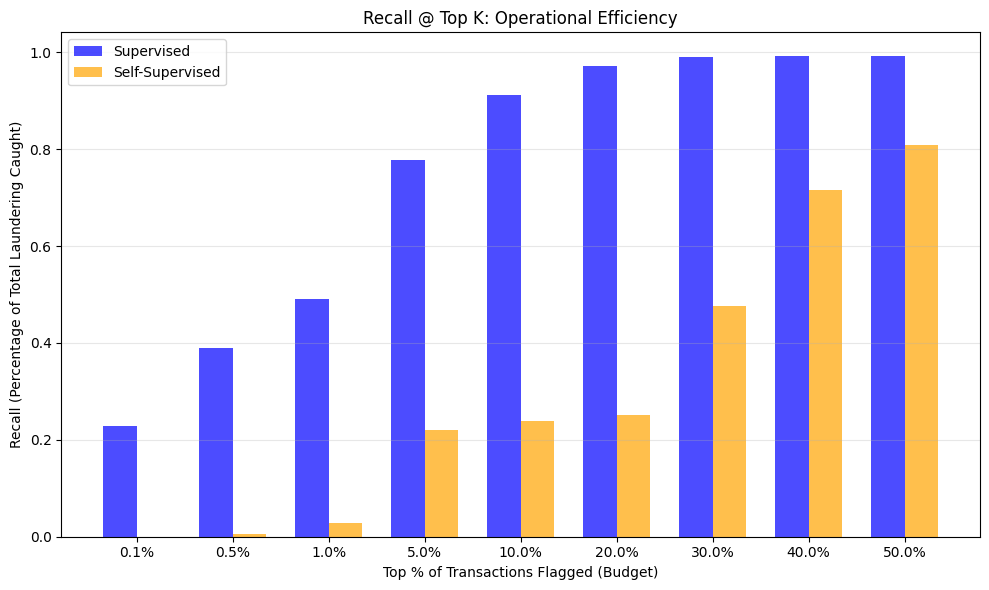


--- Operational Stats (Recall @ Top K) ---
  Top K %  Alerts Generated  Sup Recall  Unsup Recall
0    0.1%               656    0.228916      0.000000
1    0.5%              3282    0.389157      0.006024
2    1.0%              6565    0.491566      0.028916
3    5.0%             32829    0.778313      0.219277
4   10.0%             65658    0.910843      0.238554
5   20.0%            131316    0.972289      0.250602
6   30.0%            196974    0.990361      0.475904
7   40.0%            262632    0.991566      0.715663
8   50.0%            328291    0.991566      0.808434


In [27]:
analyze_typology_and_ranking_grouped(sup_probs, anomaly_scores_send, test_df)